## **Retail Sales Analysis**

### Project Objective

This project explores retail sales data to identify customer purchasing behavior, product performance, seasonal trends, and payment preferences. The insights generated from this analysis can help businesses make data-driven decisions to improve sales and customer satisfaction.

### Business Questions

- Which product category generates the highest revenue?
- Which category has the highest number of transactions?
- How do customer demographics influence purchasing behavior?
- Which payment method is most commonly used?
- Do discounts affect customer spending?
- Which season performs best?

**import Libraries**

This section imports all the Python libraries required for data manipulation and visualization throughout the project.

In [2]:
#importing all required libraries:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported Successfully!")


All libraries imported Successfully!


**Load Dataset**

In [3]:
df = pd.read_csv("store_sales.csv")

display(df.head())

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


**Dataset Overview**

In [4]:
print("==DATASET overview==")
#Dimensions
print(f"Dataset Shape: {df.shape}")
#columns
print(f"Columns:\n{df.columns}")
#missing values
print(f"Missing Values:\n{df.isnull().sum()}")
#duplicate rows
print(f"Duplicate rows:{df.duplicated().sum()}")
#statistical summary
print(f"Statistical Summary:\n{df.describe()}")


==DATASET overview==
Dataset Shape: (5000, 11)
Columns:
Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
      dtype='str')
Missing Values:
CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64
Duplicate rows:0
Statistical Summary:
        CustomerID          Age       Amount   ItemRating  DiscountApplied(%)  \
count  5000.000000  5000.000000  5000.000000  5000.000000         5000.000000   
mean   2500.500000    45.224800   285.090522     3.784160           14.983600   
std    1443.520003    14.564995   551.454382     0.681796            5.988063   
min       1.000000    20.000000     5.080000     1.100000            0.000000   
25%    1250.7

### **Dataset Summary**

- The dataset contains 5000 rows and 11 columns.
- No missing values were found across the dataset.
- No duplicate records were detected.
- Numerical features include customer age, quantity purchased, and total amount.
- Categorical features include gender, product category, season, payment method, and discount status.

The dataset appears clean and suitable for exploratory data analysis.

## **Customer Analysis**

- **Transaction Count by Gender**


This section checks the balance between male and female customers for further analysis of spending patterns.

Gender
Female    2504
Male      2496
Name: count, dtype: int64


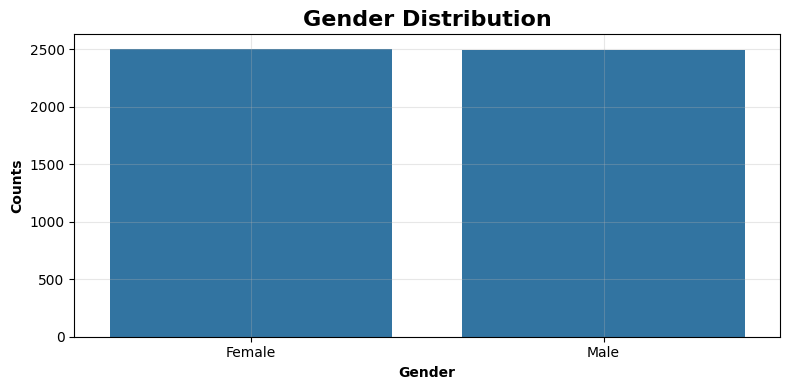

In [5]:
#Visualizing the counts of male and female customers.

gender_count=df['Gender'].value_counts()
print(gender_count)

plt.figure(figsize=(8,4))
sns.barplot(gender_count)
plt.xlabel("Gender",fontweight='bold',fontsize=10)
plt.ylabel("Counts",fontweight='bold',fontsize=10)
plt.grid(True,alpha=0.3)
plt.title("Gender Distribution",fontweight='bold',fontsize=16)
plt.tight_layout()
plt.show()


 - Gender Distribution is nearly balanced:(Male:2496 and female:2504)

 - Indicating no significance skew toward either gender in this customer base




- **Transaction Count by Age**

Analyzing the distribution of customer ages using summary statistics and visualize using histogram.

count      4922
unique        5
top       41-50
freq       1048
Name: AgeGroup, dtype: object
AgeGroup
41-50    1048
51-60    1019
20-30     963
61-70     952
31-40     940
Name: count, dtype: int64


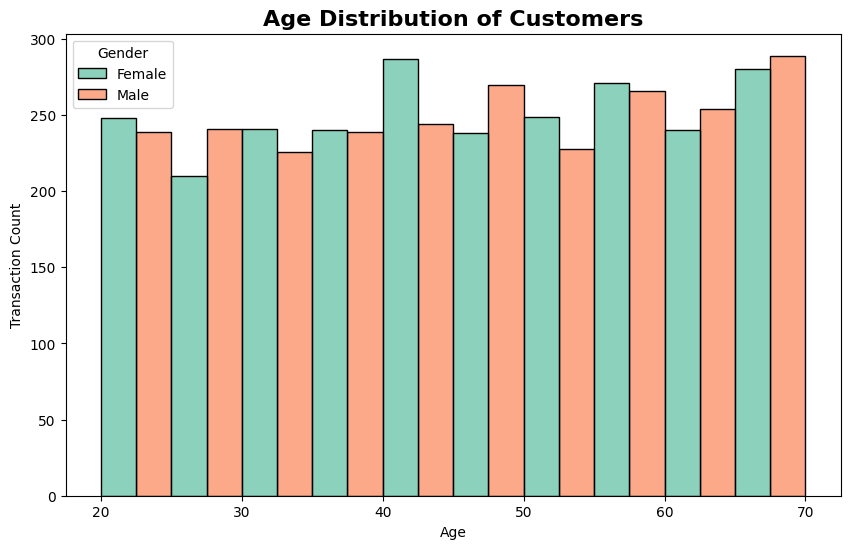

In [6]:
#Age Analysis
df["AgeGroup"]=pd.cut(df['Age'],bins=[20,30,40,50,60,70],labels=['20-30','31-40','41-50','51-60','61-70'])
print(df['AgeGroup'].describe())
print(df["AgeGroup"].value_counts().sort_values(ascending=False))

#visualizing Age-wise Transactions count
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='Age',
    bins=10,
    hue='Gender',
    multiple='dodge',
    palette="Set2",
)
plt.xlabel("Age")
plt.ylabel("Transaction Count")
plt.title("Age Distribution of Customers",fontweight='bold',fontsize=16)
plt.show()


### Key-insights:

The age distribution is also almost balanced but the age group 41-60 have more transactions.


- **Revenue by Gender**

This analysis compares the revenue generated by male and female customers to understand spending patterns and support targeted marketing strategies, personalized promotions, and business decision-making.

Gender
Male      460.622580
Female    110.119269
Name: Amount, dtype: float64
Gender
Male      1149713.96
Female     275738.65
Name: Amount, dtype: float64


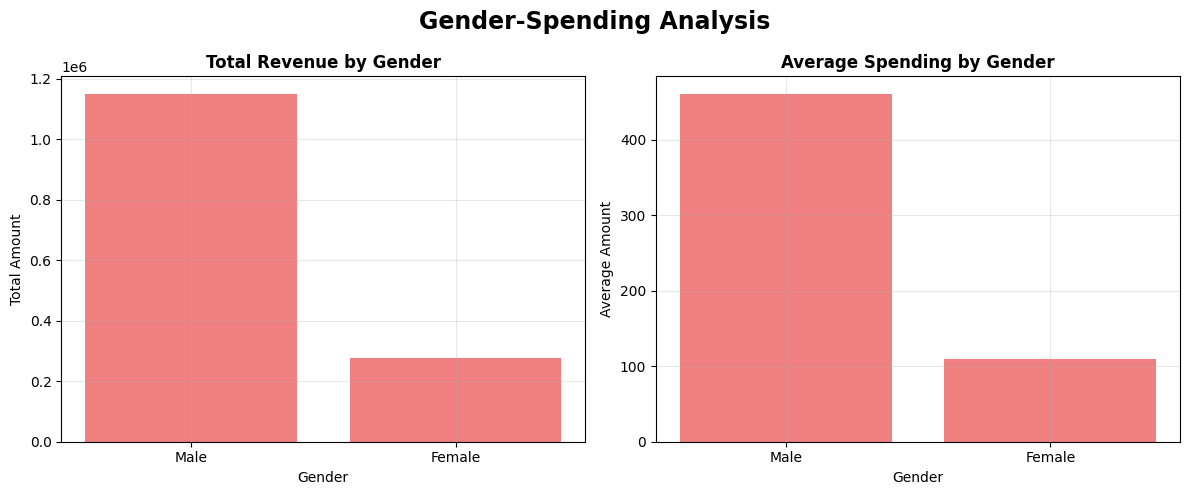

In [13]:
average_spending_by_gender=df.groupby('Gender')["Amount"].mean().sort_values(ascending=False)
print(average_spending_by_gender)

total_revenue_by_gender=df.groupby('Gender')["Amount"].sum().sort_values(ascending=False)
print(total_revenue_by_gender)

fig, axes=plt.subplots(1,2,figsize=(12,5))
axes[0].bar(total_revenue_by_gender.index,total_revenue_by_gender.values,color="lightcoral")
axes[1].bar(average_spending_by_gender.index,average_spending_by_gender.values,color="lightcoral")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Total Amount")
axes[0].set_title("Total Revenue by Gender",fontweight='bold')
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Average Amount")
axes[1].set_title("Average Spending by Gender",fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle("Gender-Spending Analysis",fontweight='bold',fontsize=17)
plt.savefig("gender_spending_analysis.png",dpi=150)
plt.tight_layout()
plt.show()


### Key-insights:

Male customers spend more on average and contribute a larger share of total revenue, despite female customers having slightly more transactions. This suggests that male customers tend to make higher-value purchases.

## **"Seasonal Analysis"**

- **Transaction Count by Season**

This section analyzes transaction trends across different seasons.

count       5000
unique         4
top       Spring
freq        1300
Name: Season, dtype: object
Season
Spring    1300
Winter    1244
Autumn    1231
Summer    1225
Name: count, dtype: int64


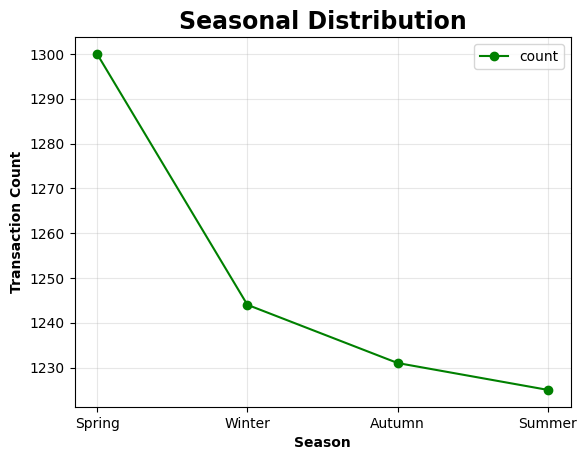

In [8]:
#This cell analyzes the distributions of different seasons

print(df['Season'].describe())
print(df['Season'].value_counts())

plt.plot(df['Season'].value_counts().index,df['Season'].value_counts().values,color='green',marker='o',label="count")
plt.xlabel("Season",fontweight='bold',fontsize=10)
plt.ylabel("Transaction Count",fontweight='bold',fontsize=10)
plt.title("Seasonal Distribution",fontweight='bold',fontsize=17)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Key-insights:

The Transactions count is almost balanced accross seasons with top at spring with 1300 transactions.

- **Seasonal Performance Overview**

This section analyzes the season-wise average per transactions and total revenue.

Season
Spring    289.253385
Summer    286.416620
Winter    285.277299
Autumn    279.185938
Name: Amount, dtype: float64
Season
Spring    376029.40
Winter    354884.96
Summer    350860.36
Autumn    343677.89
Name: Amount, dtype: float64


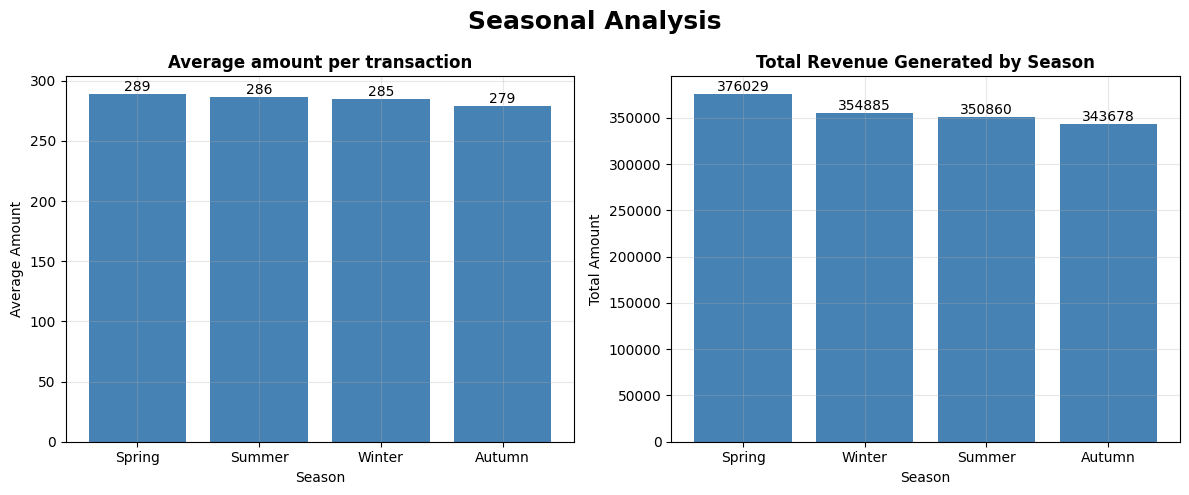

In [12]:
seasonal_average_purchase=df.groupby('Season')["Amount"].mean().sort_values(ascending=False)
print(seasonal_average_purchase)

seasonal_revenue=df.groupby('Season')["Amount"].sum().sort_values(ascending=False)
print(seasonal_revenue)

fig, axes=plt.subplots(1,2,figsize=(12,5))
bars1=axes[0].bar(seasonal_average_purchase.index,seasonal_average_purchase.values,color="steelblue")
axes[0].bar_label(bars1,fmt="%.0f")

bars2=axes[1].bar(seasonal_revenue.index,seasonal_revenue.values,color="steelblue")
axes[1].bar_label(bars2,fmt="%.0f")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average Amount")
axes[0].set_title("Average amount per transaction",fontweight='bold')
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Total Amount")
axes[1].set_title("Total Revenue Generated by Season",fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle("Seasonal Analysis",fontweight='bold',fontsize=18)
plt.savefig("seasonal_analysis.png",dpi=150)
plt.tight_layout()
plt.show()

### Key-insights:

The average transaction amount is relatively consistent across all seasons, while Spring generates the highest total revenue.

## **Category Analysis**



- **Transaction Count by Category:**

This section analyzes the number of transactions across different product categories.

Category
Footwear           983
Sports             835
Womens Clothing    547
Beauty             529
Mens Clothing      511
Electronics        507
Accessories        470
Groceries          332
Home               286
Name: count, dtype: int64


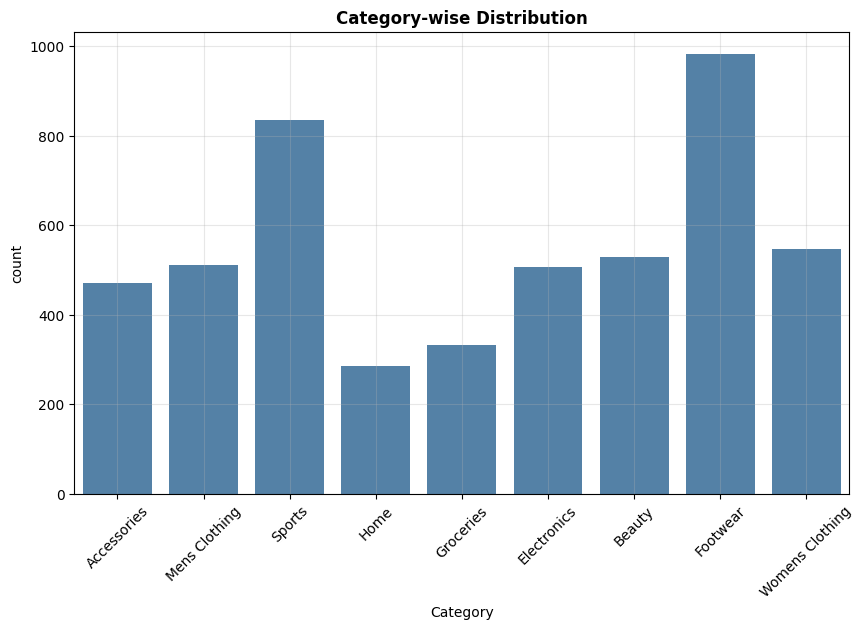

In [ ]:
print(df["Category"].value_counts())

#visualizing Category wise distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Category",color='steelblue')
plt.title("Category-wise Distribution",fontweight="bold")
plt.xticks(rotation=45)
plt.grid(True,alpha=0.3)
plt.show()

### Key-insights

Footwear leads in transaction count , but this doesn't necessarily reflect its revenue contribution.

That comparison follows in the next section.

- **Categorical Performance Overview**

This section analyzes which product category contributes the most to overall revenue and which category records the highest number of transactions.



                       sum  count         mean
Category                                      
Accessories       47633.83    470   101.348574
Beauty            43887.06    529    82.962306
Electronics      895402.35    507  1766.079586
Footwear         141142.24    983   143.583154
Groceries         14015.96    332    42.216747
Home              46374.22    286   162.147622
Mens Clothing     59680.43    511   116.791448
Sports           115598.11    835   138.440850
Womens Clothing   61718.41    547   112.830731


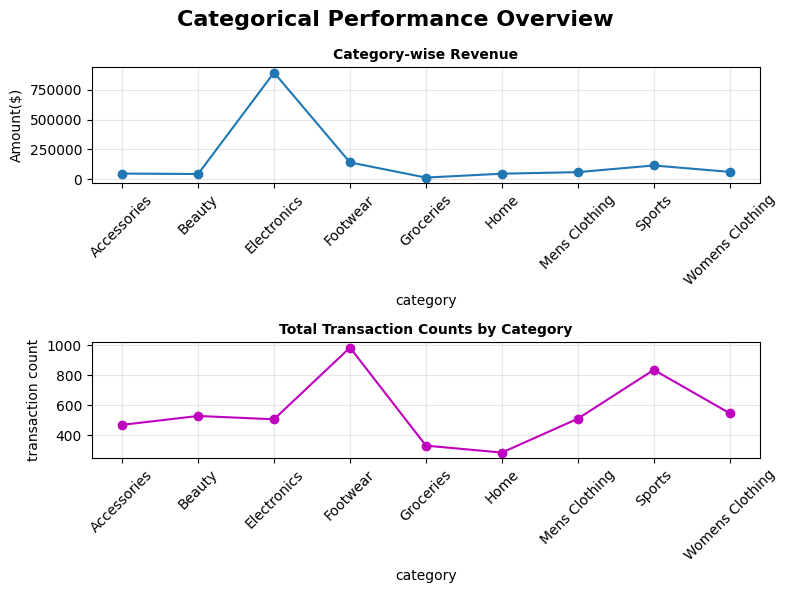

In [14]:
#Comparison of category with more revenure and category with more transactions.

category_performance=df.groupby("Category")['Amount'].agg(['sum','count','mean'])
print(category_performance)


fig, axes=plt.subplots(2,1,figsize=(8,6))
plt.suptitle("Categorical Performance Overview",fontsize=16,fontweight="bold")

axes[0].plot(category_performance.index,category_performance['sum'],marker='o')
axes[0].set_xlabel("category")
axes[0].set_ylabel("Amount($)")
axes[0].set_title("Category-wise Revenue",fontweight="bold",fontsize=10)
axes[0].tick_params(axis='x',rotation=45)
axes[0].grid(True,alpha=0.3)

axes[1].plot(category_performance.index,category_performance['count'],marker='o',color='m')
axes[1].set_xlabel("category")
axes[1].set_ylabel("transaction count")
axes[1].set_title("Total Transaction Counts by Category",fontweight="bold",fontsize=10)
axes[1].tick_params(axis='x',rotation=45)
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig("category_performance.png",dpi=150)
plt.show()


### Key-Insights:

- Electronics contributes the highest revenue.
- Footwear has the highest number of transactions.
- High sales volume does not always indicate higher revenue.

- **Categorical Performance by Rating**

This section analyzes the average rating on the Items of each Category.

Category         RatingGroup
Accessories      3-4            233
                 4-5            167
                 2-3             69
                 1-2              1
                 0-1              0
Beauty           3-4            248
                 4-5            213
                 2-3             62
                 1-2              6
                 0-1              0
Electronics      3-4            252
                 4-5            180
                 2-3             72
                 1-2              3
                 0-1              0
Footwear         3-4            449
                 4-5            378
                 2-3            148
                 1-2              8
                 0-1              0
Groceries        3-4            164
                 4-5            124
                 2-3             44
                 0-1              0
                 1-2              0
Home             3-4            136
                 4-5            109

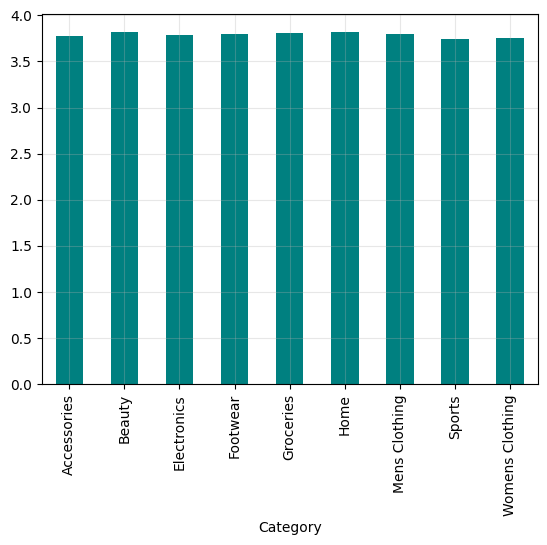

In [ ]:
#Items-Rating by Customers across product categories
df["RatingGroup"]=pd.cut(df["ItemRating"],bins=[0,1,2,3,4,5],labels=["0-1","1-2","2-3","3-4","4-5"])
print(df.groupby("Category")['RatingGroup'].value_counts())
category_rating=df.groupby("Category")['ItemRating'].mean()
print(category_rating)
category_rating.plot(kind="bar",color='teal')
plt.grid(alpha=0.3)
plt.show()


### Key-insights:

All categories have balanced same average of rating as 3.7

- **Gender-wise Performance across product categories**

This section analyzes the categorical performance accross Male and Female Customers.

==CATEGORY PERFORMANCE BY GENDER==
                              sum  count         mean
Category        Gender                               
Accessories     Female   47633.83    470   101.348574
Beauty          Female   43887.06    529    82.962306
Electronics     Male    895402.35    507  1766.079586
Footwear        Female   68669.12    476   144.262857
                Male     72473.12    507   142.945010
Groceries       Female    7208.50    168    42.907738
                Male      6807.46    164    41.508902
Home            Female   23208.36    141   164.598298
                Male     23165.86    145   159.764552
Mens Clothing   Male     59680.43    511   116.791448
Sports          Female   23413.37    173   135.337399
                Male     92184.74    662   139.251873
Womens Clothing Female   61718.41    547   112.830731


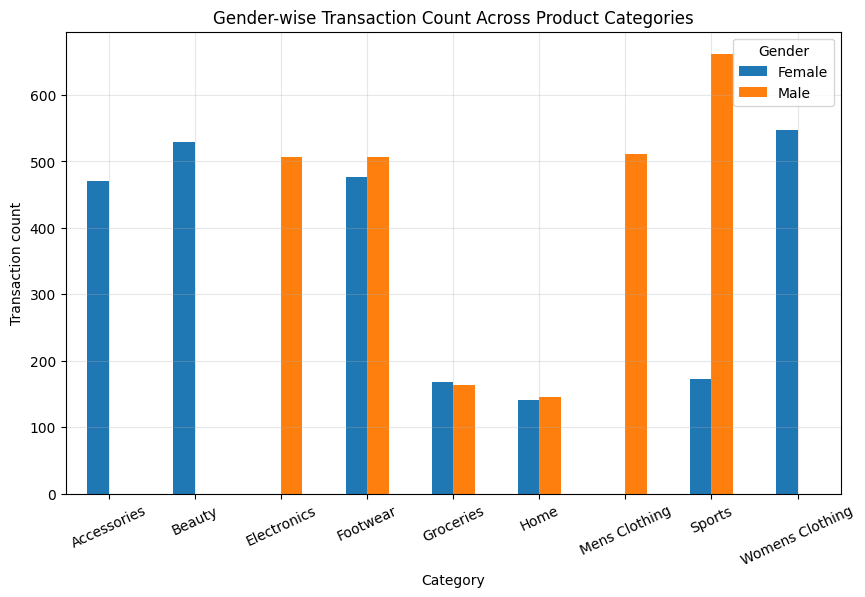

In [ ]:
print("==CATEGORY PERFORMANCE BY GENDER==")
category_by_gender=df.groupby(["Category","Gender"])["Amount"].agg(["sum","count","mean"])
print(category_by_gender)
pd.crosstab(df["Category"],df["Gender"]).plot(kind="bar",figsize=(10,6))
plt.xlabel("Category")
plt.ylabel("Transaction count")
plt.title("Gender-wise Transaction Count Across Product Categories")
plt.grid(True,alpha=0.3)
plt.xticks(rotation=25)
plt.show()



### Key-Insights:

Clear gender-based preferences emerge across product categories. Accessories and Beauty are 
purchased almost exclusively by female customers, while Electronics shows a strong male dominance. 
Sports also skews heavily male, with relatively few female purchases. As expected, Women's Clothing 
and Men's Clothing are purchased almost entirely by their respective target genders. Minor variations 
exist across the remaining categories as well.

This directly explains the earlier finding that male customers contribute more to total revenue ,
their purchases are concentrated in Electronics, a category with a high average transaction value.

- **Season-wise Performance Across Product Categories**

==CATEGORY PERFROMANCE BY SEASONS==
                              sum  count         mean
Category        Season                               
Accessories     Autumn   11100.42    112    99.110893
                Spring   12480.54    120   104.004500
                Summer   12105.55    116   104.358190
                Winter   11947.32    122    97.928852
Beauty          Autumn   11185.59    134    83.474552
                Spring   11641.49    145    80.286138
                Summer    9258.03    113    81.929469
                Winter   11801.95    137    86.145620
Electronics     Autumn  214345.77    126  1701.156905
                Spring  236964.91    131  1808.892443
                Summer  222637.35    126  1766.963095
                Winter  221454.32    124  1785.921935
Footwear        Autumn   32913.11    233   141.257983
                Spring   40457.32    272   148.740147
                Summer   34235.02    250   136.940080
                Winter   33536.79    228   147

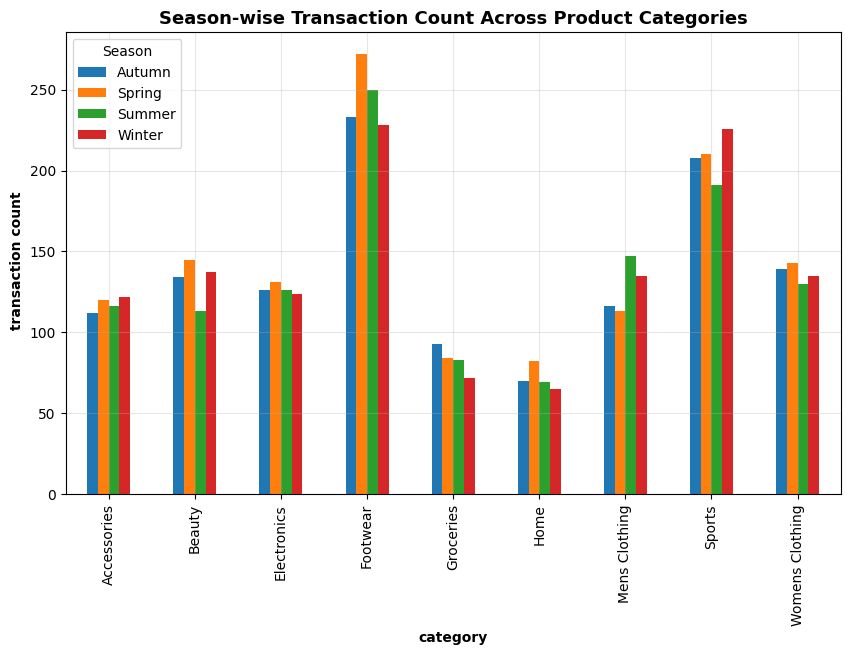

In [ ]:
print("==CATEGORY PERFROMANCE BY SEASONS==")

seasonal_categorical_performance=df.groupby(["Category","Season"])["Amount"].agg(["sum","count","mean"])
print(seasonal_categorical_performance)

#visualizing Categorical performance by Seasons
pd.crosstab(df['Category'],df['Season']).plot(kind="bar",figsize=(10,6))
plt.xlabel("category",fontweight='bold',fontsize=10)
plt.ylabel(" transaction count",fontweight='bold',fontsize=10)
plt.title("Season-wise Transaction Count Across Product Categories",fontweight='bold',fontsize=13)
plt.grid(True,alpha=0.3)
plt.show()

### Key-insights:

Spring shows a slight dominance in transaction count across most categories, with Footwear recording the most notable peak (272 transactions in Spring versus 228–250 in other seasons). This suggests Spring may be a comparatively stronger sales period overall. Spring also shows a modest lead in Electronics — the category contributing most to total business revenue. This reinforce its position as a season worth prioritizing for inventory and marketing focus.


## **Payment Method Analysis**

==PAYMENT METHOD ANAYLSIS==
PaymentMethod
Card                4009
Cash on Delivery     991
Name: count, dtype: int64
                         sum  count        mean
PaymentMethod                                  
Card              1366289.67   4009  340.805605
Cash on Delivery    59162.94    991   59.700242


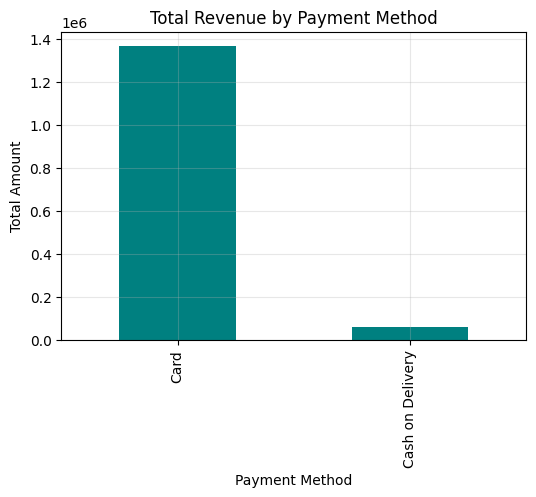

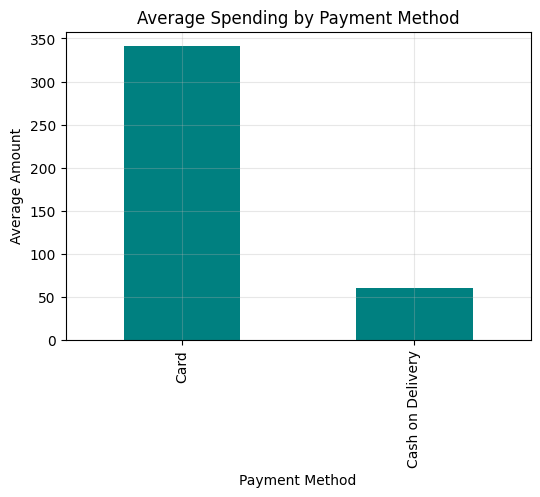

In [ ]:

print("==PAYMENT METHOD ANAYLSIS==")
print(df["PaymentMethod"].value_counts())

payment_method_analysis=df.groupby("PaymentMethod")["Amount"].agg(['sum','count','mean'])
print(payment_method_analysis)

payment_method_analysis['sum'].plot(kind="bar",figsize=(6,4),color="teal")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount")
plt.title("Total Revenue by Payment Method")
plt.grid(True,alpha=0.3)
plt.show()
payment_method_analysis['mean'].plot(kind="bar",figsize=(6,4),color="teal")
plt.xlabel("Payment Method")
plt.ylabel("Average Amount")
plt.grid(True,alpha=0.3)
plt.title("Average Spending by Payment Method")
plt.show()

### Key-insights:

Card Payments contribute to a larger share of total business revenue and card customers show higher average spending compared to COD customers

## **Discount Analysis**

DiscountApplied(%)
16    351
18    346
12    340
20    318
10    318
8     304
15    303
13    300
14    299
22    255
17    237
11    236
6     204
24    179
19    171
9     143
4     138
26    117
21     97
28     64
2      55
23     55
7      48
30     35
25     31
32     16
5      12
0       9
27      7
29      6
34      5
36      1
Name: count, dtype: int64


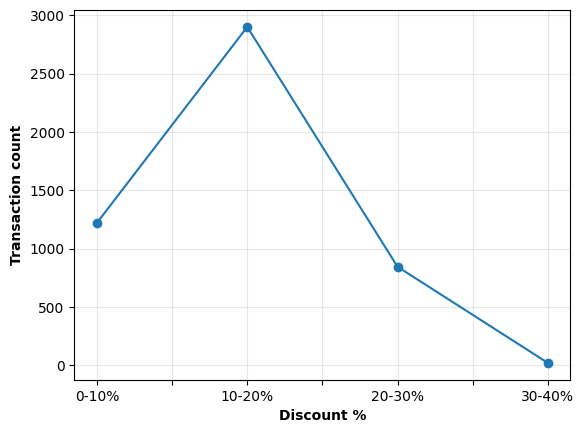

Correlation between Item Amount and Discount Applied:0.004291058632322841


In [ ]:
print(df["DiscountApplied(%)"].value_counts())

df["DiscountGroup"]=pd.cut(df["DiscountApplied(%)"],bins=[0,10,20,30,40],labels=["0-10%","10-20%","20-30%","30-40%"])
#made discount price groups so visualization could be smooth and clear
df["DiscountGroup"].value_counts().sort_index().plot(kind="line",marker="o")
plt.xlabel("Discount %",fontweight="bold")
plt.ylabel("Transaction count",fontweight="bold")
plt.grid(True,alpha=0.3)
plt.show()

print(f"Correlation between Item Amount and Discount Applied:{df["Amount"].corr(df["DiscountApplied(%)"])}")

### Key-insights:

The transactions are more occur in discount range 10-20% (~ 28000 transactions) while both lower (0-10%)

and higher (20-40%) discount ranges have noticably fewer transactions. But this reflect transaction frequency only while 

further analysis e.g by category or amount would be needed to determine whether this discount range is associated with higher

spending or more specific product types.

## **Key-Insights Summary**


**Customer Demographics**
- Gender distribution is nearly balanced (Male: 2,496, Female: 2,504), with no significant skew.
- Age distribution spans 20–70 years, with the 41–60 age group showing slightly more transactions.

**Revenue & Spending**
- Male customers contribute more to total revenue and show higher average spending, despite 
  females having marginally more transactions. This is largely explained by category preferences that
  males dominate Electronics purchases, a category with a significantly higher average transaction value.

**Category Performance**
- Footwear leads in transaction count, but **Electronics generates the highest revenue** 
  (15–20x higher than other categories), despite a comparable number of transactions. This 
  highlights that transaction volume and revenue contribution are not the same thing.
- Category preferences are strongly gender-segmented: Accessories and Beauty skew female; 
  Electronics and Sports skew male; clothing categories align with their respective genders.
- Item ratings are consistent across categories (~3.7 average), indicating no category stands 
  out in customer satisfaction.

**Seasonal Trends**
- Category performance is largely stable across seasons. Spring shows a mild, consistent edge in 
  transaction count across several categories, most notably Footwear (272 transactions vs. 228–250 
  in other seasons).

**Payment & Discounts**
- Card payments contribute a larger share of total revenue, with card customers showing higher 
  average spending than Cash on Delivery (COD) customers.
- Transactions are concentrated in the 10–20% discount range (~2,800 transactions),though this reflects only frequency only as no strong correlation was found between discount level and transaction amount(correlation ~ 0.44)

## **Recommendations**

1. **Prioritize Electronics in marketing and inventory planning** — it drives disproportionately 
   high revenue relative to transaction volume, making it the most valuable category per sale.

2. **Tailor marketing by gender and category** — given strong gender segmentation (e.g., Electronics 
   skewing male, Beauty skewing female), targeted campaigns are likely to be more effective than 
   generic, non-segmented promotions.

3. **Encourage card payments** — since card users show higher average spending, incentives like 
   card-exclusive discounts could help increase average order value.

4. **Consider light seasonal promotion for Footwear in Spring**, where transaction volume is 
   consistently higher — though this should be weighed against the modest scale of the effect.

5. **Re-evaluate discount strategy** — since discount level shows no meaningful relationship with 
   spending amount, discounts in the 10–20% range may be more about driving transaction frequency 
   than increasing revenue per sale. Testing different discount tiers could clarify their actual 
   impact on customer behavior.

6. **Improve product and service quality to boost customer satisfaction** — the average item 
   rating across all categories is 3.7 out of 5, indicating room for improvement.